In [1]:
!pip install bertopic datasets datamapplot

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 350.6/350.6 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 22.1 MB/s eta 0:00:00
  Created wheel for Pyqtree: filename=pyqtree-1.0.0-py3-none-any.whl size=6015 sha256=ede31588ac5afa67ab01bf80c28e203b16872468945c5765701db0cde13e2065
  Stored in directory: /root/.cache/pip/wheels/26/ac/8e/a8dbbd10225dba324f71ab0a90648de4ad94087b0c9fd81550
Successfully built Pyqtree
  Attempting uninstall: dask
    Found existing installation: dask 2026.1.1
    Uninstalling dask-2026.1.1:
      Successful

# 零、总述

本章主要探讨生成模型和表示模型如何在**无监督学习**领域发挥作用，尽管有监督算法比较盛行，但**无监督的方法由于能够在无需提前标注的情况下基于语义内容对文本进行分组，仍然具有巨大潜力**

下面要介绍的**文本聚类（Text Clustering）** 和 **主题建模(Topic Modeling)** 就是属于无监督学习算法

*文本聚类* 旨在基于文本的语义内容、含义和关系对相似文本进行分组

<img src="./resources/text_clustering.png">


*主题建模* 旨在找出这些文本都在讨论哪些主题，所以它关注的问题是：一个文本集合中，隐藏着哪些主题？每个文本又包含哪些主题？

<img src="./resources/topic_modeling.png">



首先，我们先探索如何使用嵌入模型进行聚类，然后过渡到一种受文本聚类启发的主题建模方法，即 BERTopic。

在本章中，我们将在 ArXiv 文章上运行聚类和主题建模算法。ArXiv 是一个主要面向计算机科学、数学和物理领域的开放的学术文章平台。下面我们将探索计算与语言领域的文章，对应于 arxiv_nlp 这一数据集，它包含 1991 年至 2024 年间来自 ArXiv cs.CL 板块的 44949 篇摘要。

下面我们加载数据，做数据准备

In [2]:
from datasets import load_dataset
dataset = load_dataset("maartengr/arxiv_nlp")["train"]

abstracts = dataset["Abstracts"]
titles = dataset["Titles"]

README.md:   0%|          | 0.00/617 [00:00<?, ?B/s]

data.csv: reconstructing file:   0%|          |  0.00B / 53.2MB            

data.csv: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

# 一、文本聚类的通用流程

文本聚类不仅可以发现已知的数据模式，更可以挖掘不为人知的数据模式，它可以帮助你直观地理解任务及其复杂性。虽然文本聚类的方法有很多，从基于图的神经网络到基于质心的聚类技术，但当前比较流行的通用流程主要包含以下三个步骤（Embedding -> Reduction -> Cluster）：
1. 使用**嵌入模型（Embedding Model）** 将输入文档转换为嵌入向量
2. 使用**降维模型（Dimensionality Reduction Model）** 将嵌入向量降至更低维度空间
3. 使用**聚类模型（Cluster Model）** 对降维后的嵌入向量进行聚类


<img src="./resources/text_clustering_processing.png">

## 1.1 嵌入文档

这里我们选择 thenlper/gte-small 模型来作为嵌入模型

In [3]:
from sentence_transformers import SentenceTransformer

# 为每个摘要创建嵌入向量
embedding_model = SentenceTransformer("thenlper/gte-small")
embeddings = embedding_model.encode(abstracts, show_progress_bar=True)

modules.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/68.1k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/583 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 66.7MB            

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/712k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1405 [00:00<?, ?it/s]

In [4]:
embeddings.shape

(44949, 384)

我们可以看到嵌入向量的维度为 384 维，即每个摘要的语义表示（向量表示）包含了 384 个值

## 1.2 嵌入向量降维

降维：高维空间 -> 低维空间

**降维** 会带来两个问题：第一个是计算量会变得很大，但最主要的还是第二个：**高维空间会使数据变得非常“稀疏”**，也就是说，**维度越高，点之间距离越远**，其原理基于欧式距离的公式，公式如下：
$$
D = \sqrt{(a_1 - b_1)^2 + (a_2 - b_2)^2 + \cdot + (a_d - b_d)^2}
$$

因此，**距离会随着维度的平方根增长**，并且会带来一个很重要的问题：**距离的区分能力下降**，也就是*最近的点和最远的点之间，相对差异越来越小*，例如低维空间：
```text
最近邻：0.2
最远点：3.0
```

但是到达了高维空间之后，它会变成：
```text
最近邻：400
最远点：430
```

所以，**降维**不仅是为了减少计算量，更重要的是把数据从过于稀疏的高维空间压缩到一个更紧凑、更有意义的低维表示空间中。还有一点需要补充的是：**维度不是越低越好**，那样会丢失大量的有用信息，所以要在信息保留与降维之间做权衡。

我们介绍两个降维的方法：主成分分析（Principal Component Analysis,**PCA**）和统一流行逼近和投影(Uniform Manifold Approximation and Projection, **UMAP**)。

1. PCA: 主成分分析

它是一种经典的**线性降维算法**。PCA 将数据投影到一组新的正交坐标轴上，这些轴按照能够解释的数据方差从大到小排列。它核心的思想是**找到数据变化最大的方向，然后把数据投影到这些方向上**

2. UMAP：统一流行逼近和投影

它是一种**非线性降维算法/流形学习算法**，它更关注“谁和谁是邻居”，它的核心目标之一是**让低维空间尽量保持高维数据中的邻域结构**

本次流程我们使用的是 UMAP，因为它在处理非线性关系和结构方面比 PCA 表现更好

In [5]:
from umap import UMAP

# 将嵌入向量从 384 维降至 5 维
umap_model = UMAP(
    n_components=5,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

reduced_embeddings = umap_model.fit_transform(embeddings)

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [6]:
reduced_embeddings.shape

(44949, 5)

## 1.3 对降维后的嵌入向量进行聚类

聚类可以用于各种应用程序，包括：
- **客户细分**：你可以根据客户的购买记录和他们在网站上的活动对客户进行聚类
- **数据分析**
- **特征工程**
- **异常检测**：也叫离群值检测
- **半监督学习**
- **搜索引擎**：一些搜索引擎可让你搜索参考图像相似的图像
- **图像分割**：根据像素的颜色对像素进行聚类，然后用其聚类的平均颜色替换每个像素的颜色
- 等等。。。

关于聚类没有统一的定义，它实际上取决于上下文，并且不同的算法会得到不同种类的集群。一些算法会寻找围绕特定点（称为质心）的实例。其他算法则寻找密集实例连续区域：这些集群可以呈现任何形状

### 聚类算法介绍

#### 1. K-Means 算法

KMeans 算法通过将样本分成 n 个相同方差的组来对数据进行聚类，它是会最小化一个被称为**惯性**（inertia）的指标或**簇内平方和**，公式如下：

$$
\sum_{i=0}^n \min_{\mu_j \in C}(||x_i - \mu_j||^2)
$$

K-Means 算法需指定簇的数量，它会将样本集 $X$ 分成 $K$ 个互不连接的 $C$ 个簇，每个簇都被簇中样本的平均值 $u_j$ 描述。这通常被称为簇的质心（centroids）, 这些质心并不是 $X$ 的样本点，即使它们处在相同的空间中。

惯性（Inertia）可以被当作是衡量每个簇有多么连贯，多么紧凑的指标。但是它也有一些缺点：
- 惯性（Inertia） 假设簇是**凸的**并且是**各向同性的**，但现实中的数据集并不总是这样。对于一些细长型的簇，以及有不规则形状的流形簇，它表现的不是很好
- 惯性（Inertia）不是一个归一化的指标：我们仅仅是将这个值降到最优，也就是0。但是，在高维空间中，欧式距离往往会被放大（这就是所谓的**维度的诅咒(curse of dimensionality)**）。所以，在执行 KMeans 算法之前需进行一个；类似于 PCA 的降维方法，不仅可以解除维度的诅咒，而且还可以加速计算

这里讲两个概念：**凸的（凸集）** 和 **各向同性**
a. 凸的（凸集，convex set）

直观的理解为：*在一个集合内部任意选两个点，把这两个点用一条直线连起来，整条线段仍在此集合内部*，那么这个集合就是凸集

在数学上，如果对于任意两个点 $x_1, x_2 \in C$，以及任意 $0 \le \lambda \le 1$, 都有：
$$
\lambda x_1 + (1 - \lambda)x_2 \in C
$$
则我们说，集合 C 是凸集，

b. 各向同性（isotropic）

从中心往各个方向看，数据的扩散程度大致相同


In [7]:
from sklearn.cluster import KMeans
import numpy as np

X = np.array([[1, 2], [1, 4], [1, 0],
              [10, 2], [10, 4], [10, 0]])

kmeans = KMeans(n_clusters=2, random_state=0, n_init="auto").fit(X)
print(kmeans.labels_)
print(kmeans.cluster_centers_)

[1 1 1 0 0 0]
[[10.  2.]
 [ 1.  2.]]


#### 2. DBSCAN 和 HDBSCAN

DBSCAN 和 HDBSCAN 都是基于密度的聚类算法，DBSCAN 的全称是 Density-Based Spatial Clustering of Applications with Noise,即“基于密度的有噪声的数据的空间聚类应用”，而多了一个 `H`，它代表 Hierarchical：分层

我们接下来逐个讲述这两个算法：

① DBSCAN

DBSCAN 算法会将 clusters(簇) 看作是由低密度区域分割的高密度区域。由于 DBSCAN 对簇的定义比较通用，因此 DBSCAN 可以发现任意形状的簇，而不是 K-Means 算法中所假设的“簇是凸形的”结构。DBSCAN 最核心的组件是 core samples 的概念，它代表在高密度区域中的样本。因此，一个簇可以理解为由以下两类样本组成：

- 一组**核心样本**：每个核心样本之间比较*接近*，这里的*接近* 是通过距离来度量的
- 一组**非核心样本**：每个样本会距离某个核心样本足够近

此算法有两个重要的参数：`min_samples` 和 `eps`, 它用来正式地定义什么叫做一个区域足够密集。

一般来说，更高的 `min_samples` 或 更小的 `eps` 都代表高密度，从而形成一个簇

更正式的来说，我们将**核心样本**定义为：**对于数据集的某一个样本，如果距离它 `eps` 的范围内至少存在 `min_samples` 个其他样本，则这个样本就是核心样本（core samples）。那这些位于 `eps` 距离范围内的样本则被称为核心样本的邻居**。

这就说明核心样本是位于向量空间中的一个高密度区域。

一个簇可以看做一组核心样本的集合，其构建过程是递归进行的：
1. 从一个核心样本开始
2. 找到它的所有邻居
3. 从这些邻居中找到同样属于核心样本的点
4. 再寻找这些核心样本的核心邻居
5. 不断重复这个过程，直到无法找到新的核心样本

一个簇还会包含一组**非核心样本**，直观来看，这些样本是簇（cluster）的边缘

任何一个核心的样本都是簇的一部分。如果一个样本不是核心样本，并且此样本离核心样本的距离至少是 `eps`，那么这个样本会被此算法视为异常值（离群值，outlier）

`min_samples` 参数主要控制算法对于噪声的容忍程度。对于噪声较多、规模较大的数据集，适当增大 `min_samples` 通常比较合适。相比之下，参数 `eps` 的选择**非常关键**，它需要根据具体的数据集以及所使用的距离函数进行合理设置，通常不能简单地使用默认值。`eps` 控制的是每个数据点的**局部邻域范围**。

如果 `eps` 设置的太小，则

- 大多数数据点可能无法形成簇
- 这些点会被标记为 `-1`，即噪声

如果 `eps` 设置的太大，则

- 原本彼此接近但应该分开的多个簇可能会被合并
- 甚至在特殊情况下，`eps` 足够大时，该算法可能将数据集识别成一个簇

关于如何选择 `eps` 这个参数，相关文献已经讨论过一些启发式方法（heuristics）。例如，我们可以根据**最近邻距离图中的膝点（a knee in the nearest neighbor distances plot）**来选择该参数

② HDBSCAN

HDBSCAN 算法可以看作是 DBSCAN 和 OPTICS 的一种扩展。更具体的说，DBSCAN 假设用于聚类的标准，也就是对密度的要求，在整个数据集上是全局一致的。

换句话说，DBSCAN 通常使用一组统一的参数来判断所有区域的密度，因此当数据集中不同簇具有**不同密度时**，DBSCAN 表现的不是很好。而 HDBSCAN 则放宽了这一假设。

它不会只使用某一个固定的密度尺度，而是会探索**所有可能的密度尺度**，并通过构建一种不同的聚类问题表示方式，来寻找在不同密度水平下都比较稳定的簇


##### 示例开始

In [8]:
# 生成数据

from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, label_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

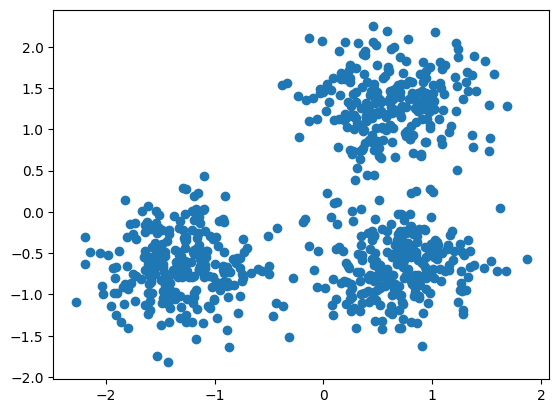

In [9]:
# 绘制图像
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [10]:
# 使用 DBSCAN 训练数据
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.3, min_samples=10).fit(X)

labels = db.labels_

# 我们看有几个簇，如果有噪声数据的话会忽略
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print(f"簇的数量为：{n_clusters_}")
print(f"噪声点的数量为：{n_noise_}")

簇的数量为：3
噪声点的数量为：18


In [11]:
# 通过指标来衡量模型的效果，以下指标越大越好

print(f"同质性(Homogeneity)：{metrics.homogeneity_score(label_true, labels):.3f}")
print(f"完整性(Completeness)： {metrics.completeness_score(label_true, labels):.3f}")
print(f"V-measure: {metrics.v_measure_score(label_true, labels):.3f}")
print(f"Adjusted Rand Index: {metrics.adjusted_rand_score(label_true, labels):.3f}")
print(f"Silhouette Coefficient(轮廓系数): {metrics.silhouette_score(X, labels):.3f}")

同质性(Homogeneity)：0.953
完整性(Completeness)： 0.883
V-measure: 0.917
Adjusted Rand Index: 0.952
Silhouette Coefficient(轮廓系数): 0.626


1. 同质性（Homogeneity）

同质性关注的是：**每一个聚类的内部，是不是尽量只包含一种真实类别的数据**，其数学原理是**条件熵**。其指标越接近1越好

2. 完整性（Completeness）

完整性关注的是：**属于同一个真实类别的数据，是不是尽量被分到了同一个簇里**，其取值范围为 0 到 1，越接近1越好

3. V-measure

它本质是把同质性和完整性放到了一起来考虑，它本质上是**Homogeneity 和 Completeness 的调和平均数**。

计算公式为：

$$
V = \frac{2}{\frac{1}{H} + \frac{1}{C}}
$$

4. Adjusted Rand Index(ARI) 调整兰德指数

ARI 的思路和前面三个不同，它关注的是**任意两个样本之间的关系**，它会**大量**比较样本A 和样本 B 的在真实标签中是否同类，在聚类结果中是否同类。ARI 的取值范围是 $[-1, 1]$，越接近1越好

- $ARI = 1$：聚类结果和真实标签高度一致
- $ARI = 0$：说明和随机划分差不多
- $ARI < 0$：比随机划分还差


5. Sihouette Coefficient:轮廓系数

它属于**内部评价指标**，无需真实标签，它直接观察数据本身的空间结构，轮廓系数主要考虑两个因素：*簇内是否紧密和簇间是否分离*。它的取值范围是 $[-1, 1]$， 越接近1越好

- $coef \approx 1$: 簇内紧密，簇间明显分离
- $coef \approx 0$: 不同簇之间发生了重叠
- $coef < 0$：很多样本可能被分错了簇



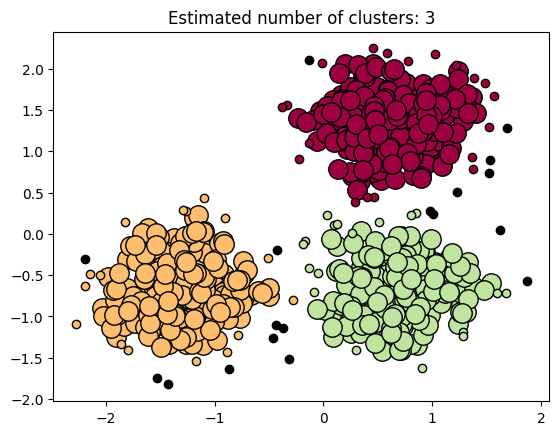

In [12]:
# 画一下分类的结果

unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        # Black used for noise.
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=14,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

plt.title(f"Estimated number of clusters: {n_clusters_}")
plt.show()

##### 示例结束

下面，让我们回归主线，这里，我们使用算法 HDBSCAN 来对上述嵌入向量进行聚类

In [13]:
from hdbscan import HDBSCAN

# 拟合模型并提取簇
hdbscan_model = HDBSCAN(
    min_cluster_size=50,
    metric="euclidean",
    cluster_selection_method="eom"
).fit(reduced_embeddings)

clusters = hdbscan_model.labels_

print(f"生成簇的数量为：{len(set(clusters))}")
print(f"簇的形状为：{clusters.shape}")

生成簇的数量为：159
簇的形状为：(44949,)


#### 3. GMM（Gaussian Mixture Models）

GMM（Gaussian Mixture Model）高斯混合模型是一种经典的概率聚类模型，它的核心思想是：**假设数据不是由一个分布产生的，而是由多个高斯分布按照一定比例混合产生的**。它和 K-Means 都可以用于聚类，但 GMM 比 K-Means 更灵活，因为它不仅考虑“数据点离中心由多远”，还会考虑每个簇的形状、方向和概率。

##### 3.1 GMM 的数学基础

对一维的随机变量 $X$ 的高斯分布存在以下概率密度函数：
$$
F_X(x) = P_X(X \le x) = \frac{1}{\sigma \sqrt{2 \pi}} \exp(-\frac{(x-\mu)^2}{2\sigma^2})
$$

其中：$\sigma$ 和 $\mu$ 分别为 $X$ 的标准差和期望。

而将高斯分布推广到 $k$ 维时，根据定义，若 $k$ 维的随机向量 $X=[X_1, ..., X_k]^T$ 服从多变量的正态分布，则存在一个对称的半正定的协方差矩阵 $\Sigma$ 以及期望向量 $\mu = [\mu_1, ..., \mu_k]^T$ 满足 $X$ 的特征函数。若 $\Sigma$ 为非奇异的，则此分布可以有以下的概率密度函数描述：

$$
f_{\mathbf{x}}(x_1, ..., x_k) = \frac{1}{\sqrt{(2 \pi)^k |\mathbf{\Sigma}|}} e^{-\frac{1}{2}(\mathbf{x} - \mathbf{\mu})^T \mathbf{\Sigma}^{-1} (\mathbf{x} - \mathbf{\mu})}
$$

其中，$|\Sigma|$ 为协方差矩阵的行列式。

而高斯混合模型为单一高斯密度函数的延伸，用多个高斯概率密度函数精确地量化变量分布，是将变量分布分解为若干基于高斯概率密度函数分布的统计自模型，每个子模型可视为此混合模型的*隐变量*。

下面讲述一下什么是*隐变量*：

在统计学中，潜变量，或称隐变量，潜在变量，**它与观测变量相对，指的是不可观测的随机变量**。潜变量可以通过使用数学模型依据观测得到的数据被推断出来。用潜在变量解释观测变量的数学模型称为潜变量模型。

##### 3.2 GMM 的详细介绍

K-Means 很擅长处理比较规则且接近圆形的数据簇。然而，现实生活中，每个簇的大小、方向和方差可能不同，两个簇甚至可能存在重叠。GMM 不仅学习**中心在哪里**，还会学习**数据如何围绕中心分布的**。

GMM 内部使用了 **EM(Expectation-Maximization, 期望最大化算法)** 来进行训练。

**最大期望算法** 在统计中被用于寻找，依赖于不可观察的隐性变量的概率模型中，参数的最大似然估计。在统计计算中，**最大期望算法是在概率模型中寻找参数最大似然估计或者最大后验估计的算法**，其中概率模型依赖于无法观测的隐变量。最大期望算法经常用在机器学习和计算机视觉的数据聚类领域。最大期望算法经过两个步骤交替进行计算，**第一步**计算期望（E 步），利用对隐藏变量的现有估计值，计算其最大似然估计值。**第二步**是最大化（M 步），最大化在 E 步上求得的最大似然值来计算参数的值。M 步上找到的参数估计值被用于下一个 E 步计算中，这个过程不断交替进行。

EM 是一个在已知部分相关变量的情况下，估计未知变量的迭代技术。EM 的算法流程如下：

1. 初始化分布参数
2. 重复直到收敛：

    2.1 E 步骤：根据参数的假设值，给出未知变量的期望估计，应用于缺失值

    2.2 M 步骤：根据未知变量的估计值，给出当前的参数的极大似然估计



##### 3.3 GMM 的实现（基于 scikit-learn库）

`class` sklearn.mixture.GaussianMixture(_n_components=1, covariance_type='full', tol=0.001, reg_covar=1e-06, max_iter=100, n_init=1, init_params='kmeans', weights_init=None, means_init=None, precisions_init=None, random_state=None, warm_start=False, verbose=0, verbose_interval=10_)

高斯混合模型概率分布的代表。此类可以使用高斯混合分布来评估参数

`参数列表如下：`

① **n_components: int, default=1**

混合的组件数量

② **covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'**

此字符串用来描述协方差矩阵的类型。

- **‘full’：** 每个组件都拥有它自己完整的协方差矩阵
- **’tied‘：** 所有组件都共享同一个完整的协方差矩阵
- **’diag‘：** 每个组件都拥有它自己的对角协方差矩阵
- **’spherical‘：** 每个组件都有它自己的单个的方差

③ **tol: float, default=1e-3**

​	收敛的阈值。当最低边界平均增益低于这个阈值的时候，EM算法迭代会停止。

④ **reg_covar：float, default=1e-6**

​	用于添加到协方差的对角线的非负正则化项。确保协方差矩阵中所有的都是正数。

⑤ **max_iter: int，default=100**

​	EM 算法的迭代次数

⑥ **n_init: int, default=1**

​	要进行初始化的次数，最好的结果可以被保留

⑦ **init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'**

​	被用于初始化权重、均值和精确率的方法。其中

- **'kmeans'：** 代表用 KMeans 算法进行初始化
- **'k-means++'：** 用 k-means++ 方法初始化
- **'random'：** 随机初始化
- **'random_from_data'：** 被随机选择的数据点的初始化均值



In [14]:
import numpy as np
from sklearn.mixture import GaussianMixture
X = np.array([[1, 2], [1, 4], [1, 0], [10, 2], [10, 4], [10, 0]])
gm = GaussianMixture(n_components=2, random_state=0).fit(X)

In [15]:
gm.means_

array([[10.,  2.],
       [ 1.,  2.]])

In [16]:
gm.predict([[0, 0], [12, 3]])

array([1, 0])

## 1.4 检查生成的簇

我们以生成的第一个簇为例

In [17]:
import numpy as np

# 打印簇 0 中的前三个文档
cluster = 0
for index in np.where(clusters==cluster)[0][:3]:
    print(abstracts[index][:100] + "... \n\n")

  This works aims to design a statistical machine translation from English text
to American Sign Lan... 


  Researches on signed languages still strongly dissociate lin- guistic issues
related on phonologic... 


  Modern computational linguistic software cannot produce important aspects of
sign language transla... 




从打印的文档来看，这个簇似乎主要包含有关手语翻译的文档

接下来，我们更进一步，可视化聚类的结果，我们将384维的向量降至二维以便于可视化（其结果仅仅是原始嵌入向量的一个近似表示）

In [18]:
import pandas as pd

reduced_embeddings = UMAP(
    n_components=2,
    min_dist=0.0,
    metric="cosine",
    random_state=42
).fit_transform(embeddings)

df = pd.DataFrame(reduced_embeddings, columns=["x", "y"])
df["title"] = titles
df["cluster"] = [str(c) for c in clusters]

# 选择离群点和非离群点
clusters_points = df.loc[df.cluster != "-1", :]
outliers_points = df.loc[df.cluster == "-1", :]

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(np.float64(-9.041299676895141),
 np.float64(11.615294313430786),
 np.float64(-7.6163016080856325),
 np.float64(11.084579062461852))

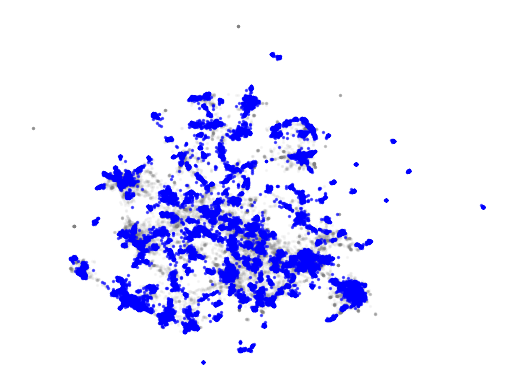

In [19]:
import matplotlib.pyplot as plt

# 分别绘制离群点和非离群点
plt.scatter(outliers_points.x, outliers_points.y, alpha=0.05, s=2, c="grey")
plt.scatter(
    clusters_points.x, clusters_points.y, c="blue",
    alpha=0.6, s=2,
)
plt.axis("off")

可以看到灰色的点均属于离群值，蓝色的点属于非离群值

# 二、从文本聚类到主题建模

从文本数据的集合中发现主题和潜在话题的思想被叫做**主题建模**。一般意义上来说，它会找到一组关键词或段落，它们最能代表和捕捉主题的含义

## 2.1 BERTopic: 一个模块化的主题建模框架


BERTopic 是一种主题建模的技术，它利用了 transformer 和 c-TF-IDF 创建稠密的聚类，从而生成易于解释的主题，同时保留主题描述中的重要词语。

此算法分为两步。

第一步，如下图所示，我们遵循文本聚类中相同的处理步骤，嵌入文档，将其降维，最终聚类降维后的嵌入层，以用来创建相似文档的语义组。

<center>
<img src="./resources/bertopic1.png">
</center>

第二步，它会在此上面建模一个分布，通过利用一种分类的方法，叫做词袋。词袋会计算每个词在文档出现的次数。这个结果表示可以被用来文档内部提取出现最频繁的词。

<center>
<img src="./resources/bertopic2.png">
</center>

不过，这里有两个需要注意的问题。

首先，这是一种文档级别的表示方式，而我们关注的是聚类级别的视角。为了解决这个问题，词频是在整个聚类中计算的，而不是仅在单个文档中计算。

其次，像 `the` 和 `I` 这样的停用词往往会频繁出现在文档中，但对于文档的实际含义几乎没有什么帮助。BERTopic 使用一种基于类别的词频-逆文档频率的变体(c-TF-IDF), 从而赋予那些对某个聚类更有意义的词更高的权重，同时降低那些在所有聚类中都会出现此的权重。

我们使用 ArXiv 数据集来运行 BERTopic，我们使用我们之前定义的模型和嵌入，我们用下图的方式来搭建 BERTopic

<center>
<img src="./resources/bertopic_block.png">
</center>

In [20]:
from bertopic import BERTopic

topic_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    verbose=True
).fit(abstracts, embeddings)

2026-09-20 08:50:33,844 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-20 08:51:31,986 - BERTopic - Dimensionality - Completed ✓
2026-09-20 08:51:31,988 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-20 08:51:34,607 - BERTopic - Cluster - Completed ✓
2026-09-20 08:51:34,630 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-20 08:51:40,501 - BERTopic - Representation - Completed ✓


让我们来看一下创建的主题有哪些。我们可以通过 `get_topic_info()`进行查看

In [21]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,15538,-1_the_of_and_to,"[the, of, and, to, in, we, for, that, language...",[ Learning to construct text representations ...
1,0,1587,0_speech_asr_recognition_end,"[speech, asr, recognition, end, acoustic, wer,...",[ Recent advances in text-to-speech (TTS) led...
2,1,1479,1_medical_clinical_biomedical_patient,"[medical, clinical, biomedical, patient, healt...",[ A common practice in the medical industry i...
3,2,1069,2_translation_nmt_machine_bleu,"[translation, nmt, machine, bleu, neural, engl...",[ The quality of machine translation is rapid...
4,3,837,3_hate_offensive_speech_detection,"[hate, offensive, speech, detection, toxic, so...",[ With growing role of social media in shapin...
...,...,...,...,...,...
154,153,54,153_counseling_mental_therapy_health,"[counseling, mental, therapy, health, psychoth...",[ Mental health care poses an increasingly se...
155,154,52,154_backdoor_attacks_attack_triggers,"[backdoor, attacks, attack, triggers, poisoned...",[ Deep neural networks (DNNs) and natural lan...
156,155,52,155_gans_gan_adversarial_generation,"[gans, gan, adversarial, generation, generativ...",[ Text generation is of particular interest i...
157,156,51,156_temporal_events_event_timeml,"[temporal, events, event, timeml, relations, r...",[ Temporal relation extraction models have th...


每一个主题都由几个关键词代表，`Name` 列中的字段使用了最能代表此主题的四个词，并使用了 `_` 拼接。

你可能还注意到，第一个主题被标记为 `-1`,这个主题包含所有无法被归入任何主题的文档，它们被视为离群点。这是聚类算法 HDBSCAN 导致的结果，因为 HDBSCAN 并不会强制所有数据点都必须划分到每个聚类中。

我们也可以通过 `get_topic` 查看每一个主题，例如，topic 0 包含了下述的关键词

In [22]:
topic_model.get_topic(0)

[('speech', np.float64(0.028533409123771385)),
 ('asr', np.float64(0.019138833922540077)),
 ('recognition', np.float64(0.013909133719155576)),
 ('end', np.float64(0.010621429434304063)),
 ('acoustic', np.float64(0.010460956236705904)),
 ('wer', np.float64(0.007447408821110592)),
 ('speaker', np.float64(0.0073356609562662605)),
 ('error', np.float64(0.006711808807312123)),
 ('ctc', np.float64(0.006453412080461576)),
 ('training', np.float64(0.0064466744613668105))]

我们还可以使用 `find_topics()` 函数来基于词搜索特定的主题，让我们来搜索一下关于 topic modeling 的主题：

In [23]:
topic_model.find_topics("topic modeling")

([25, -1, 1, 46, 39],
 [np.float64(0.9544818776383237),
  np.float64(0.9115890889009828),
  np.float64(0.9082214517245877),
  np.float64(0.9073075009451413),
  np.float64(0.9049991993776167)])

我们可以看到主题 25 和搜索词有着 0.95 的高相似度，那我们来看一下这个主题

In [24]:
topic_model.get_topic_info(25)

,Topic,Count,Name,Representation,Representative_Docs
0,25,251,25_topic_topics_lda_latent,"[topic, topics, lda, latent, documents, docume...",[ Topic models jointly learn topics and docum...


In [25]:
# 可视化主题和文档
fig = topic_model.visualize_documents(
    titles,
    reduced_embeddings=reduced_embeddings,
    width=1200,
    hide_annotations=True
)

# 更新字体大小
fig.update_layout(font=dict(size=16))

让我们探索一下其他的图

In [26]:
topic_model.visualize_barchart()

In [28]:
topic_model.visualize_heatmap(n_clusters=30)

我们来展示一下 BERTopic 中各个 Topic 之间的层次关系，使用`visualize_hierarchy()` 来查看，它会把相似的 Topic 逐步合并，画成一棵**层次聚类树（dendrogram）**。 BERTopic 默认基于 Topic 表示之间的余弦距离，再使用 Ward linkage 做层次距离。所以，可以将其理解为：

```text
Topic 3 ─┐
         ├── 更大的主题 A ─┐
Topic 8 ─┘               │
                         ├── 更大的上层主题
Topic 2 ─┐               │
         ├── 更大的主题 B ─┘
Topic 5 ─┘
```

越早合并的说明主题越相似


In [29]:
topic_model.visualize_hierarchy()

## 2.2 添加特殊的 “乐高积木块”（主题词表示优化）

到目前为止，我们所探索的 BERTopic 流程虽然速度快且具有模块化的特点，但它存在一个缺点：它仍然通过词袋模型来表示主题，没有考虑语义结构。

一个改进的方法是利用词袋模型表示的长处，那就是它能快速生成有意义的表示。首先，我们可以使用有意义的表示，随后使用更有效但是比较慢的技术去调整它，例如嵌入模型。如下图所示，我们可以重排词的初始分布来改善最终的表示。

因此，我们可以设计一个新的乐高模块，如图所示，它首先接收主题的表示，之后输出改进后的表示。

<center>
<img src="./resources/reranker_block_in_representation.png">
</center>

在 BERTopic 中，像这样的 reranker 模型将其称为 *表示模型*。这个方法主要的好处就是对主题表示的优化仅需要按照主题的数量来执行。如果有数十亿个文档和数百个主题，这个表示块仅需要对每个主题执行一次而不是对每一篇文档执行

在我们探索如何使用表示块之前，我们先来做两件事。

第一，我们保存原始的主题表示，以方便比较

第二，我们写一个 wrapper 来可视化主题词的差异，进而比较有表示模型和无表示模型的结果

In [30]:
# 1. 保存原始的表示
from copy import deepcopy
original_topics = deepcopy(topic_model.topic_representations_)

In [31]:
# 2. 可视化差异
def topic_differences(model, original_topics, nr_topics=5):
    """展示两个模型主题表示的差异"""
    df = pd.DataFrame(columns=["Topic", "Original", "Updated"])
    for topic in range(nr_topics):
        # 提取每个模型每个主题的前 5 个词
        og_words = "|".join(list(zip(*original_topics[topic]))[0][:5])
        new_words = "|".join(list(zip(*model.get_topic(topic)))[0][:5])
        # 每次都在最后一行新增数据
        df.loc[len(df)] = [topic,og_words, new_words]

    return df

### KeyBERTInspired

我们首先要探索的表示模块是 `KeyBERTInpired`。顾名思义，`KeyBERTInspired` 是一种受到关键词提取工具包 `KeyBERT` 启发的方法。`KeyBERT` 通过余弦相似度比较词嵌入与文档嵌入，从文本中提取关键词。

BERTopic 使用了类似的方法。`KeyBERTInspired` 首先利用 c-TF-IDF, 通过计算文档的 c-TF-IDF 值与其所属主题的 c-TD-IDF 值之间的相似度，为每个主题提取最具代表性的文档。

如下图所示，随后会计算每个主题中文档嵌入的平均值，并将其与候选关键词的嵌入进行比较，从而对这些关键词重新排序

由于 BERTopic 的模块化特性，我们可以使用 KeyBERTInspired 来代替我们的最初的主题表示，那么就无需降维和聚类了

In [32]:
from bertopic.representation import KeyBERTInspired

# 使用 KeyBERTInspired 来更新主题的表示
representation_model = KeyBERTInspired()
topic_model.update_topics(abstracts, representation_model=representation_model)

# 展示主题的差异性
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech|asr|recognition|end|acoustic,speech|language|phonetic|translation|transcrip...
1,1,medical|clinical|biomedical|patient|health,clinical|nlp|ehr|medicine|corpus
2,2,translation|nmt|machine|bleu|neural,translation|translations|multilingual|translat...
3,3,hate|offensive|speech|detection|toxic,hate|hateful|language|offensive|cyberbullying
4,4,relation|extraction|re|relations|entity,relation|relations|relational|sentences|extrac...


### Maximal Marginal Relevance（最大边际相关性）

使用 c-TF-IDF 和前面介绍的 `KeyBERTInspired` 技术时，最终得到的主题表示中仍然存在较多冗余。例如，在一个主题表示中同时出现 "summaries" 和 "summary" 这两个词就会造成冗余，因为他们的含义非常相近。

我们可以使用最大边际相关性（MMR）来保证主题表示的多样性。这个算法试图找到这样一组关键词：它们彼此之间具有较高的差异性，同时又与所比较的文档保持相关。它的做法是先对一组候选关键词进行嵌入，然后通过迭代计算，逐步选择下一个最适合加入的关键词。此过程需要设置一个多样性参数，用来表示关键词之间需要多大的差异程序。

In [33]:
from bertopic.representation import MaximalMarginalRelevance

# 使用 MMR 更新主题表示
representation_model = MaximalMarginalRelevance(diversity=0.5)
topic_model.update_topics(abstracts, representation_model=representation_model)

# 展示主题的差异性
topic_differences(topic_model, original_topics)

,Topic,Original,Updated
0,0,speech|asr|recognition|end|acoustic,asr|error|ctc|training|audio
1,1,medical|clinical|biomedical|patient|health,clinical|biomedical|patient|healthcare|extraction
2,2,translation|nmt|machine|bleu|neural,translation|nmt|bleu|neural|parallel
3,3,hate|offensive|speech|detection|toxic,hate|toxic|abusive|comments|platforms
4,4,relation|extraction|re|relations|entity,extraction|relations|entity|distant|sentence


### MMR 的原理

MMR（Maximal Marginal Relevance, 最大边际相关性）在选择下一个关键词时，同时考虑两件事：

1. 这个候选词和主题词有多相关？

2. 这个候选词和已经选中的词有多相似？

也就是说：

> **一个词不仅要相关，还要能提供新的信息**

MMR 的经典形式可以写成：

$$
\text{MMR}(d) = \lambda Sim(d, q) - (1 - \lambda)\max_{s \in S}Sim(d, s)
$$

其中：
- $d$ 表示当前候选关键词
- $q$ 代表主题或文档表示
- $S$ 表示已选择的关键词集合
- $Sim$ 代表相似度函数
- **$\lambda$ 控制相关性与多样性之间的权衡**

则，上述公式可以简单理解为：

$$
MMR = 相关性 - 冗余度
$$


## 2.3 文本生成的 “乐高积木块”（主题词表示优化）

在前面的示例中，BERTopic 中的表示模块一直充当着重排序模块的角色。现在，我们可以沿用部分重排序流程，在BERTopic 中高效地使用生成式模型。与其使用生成式模型去识别所有文档的主题，不如使用模型来为主题生成一个标签，因为文档的数量可能达到数百万。

如下图所示，我们不再让模型生成关键词或对关键词重新排序，而是让模型基于之前已经生成的关键词，以及一小部分具有代表性的文档，生成一个简短的主题标签。

下面，我们使用 Flan-T5 model 来作为表示模块

In [35]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
Tesla T4


In [37]:
from transformers import pipeline
from bertopic.representation import TextGeneration

prompt = """I have a topic that contains the following documents:
[DOCUMENTS]

The topic is described by the following keywords: '[KEYWORDS]'.

Based on the documents and keywords, what is this topic about?"""


# 使用 Flan-T5 更新主题的表示
generator = pipeline(
    'text2text-generation',
    model='google/flan-t5-small',
    device=0
    )

# generator = pipeline(
#     "text-generation",
#     model="Qwen/Qwen2.5-0.5B-Instruct",
#     device=0
# )

representation_model = TextGeneration(
    generator,
    prompt=prompt,
    doc_length=50,
    tokenizer="whitespace",
    pipeline_kwargs={
        "max_new_tokens": 20,
        "do_sample": False,
        "clean_up_tokenization_spaces": False
    }
)
topic_model.update_topics(abstracts, representation_model=representation_model)

# 展示主题的差异
topic_differences(topic_model, original_topics)

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

  0%|          | 0/159 [00:00<?, ?it/s][transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
100%|██████████| 159/159 [05:09<00:00,  1.95s/it]


,Topic,Original,Updated
0,0,speech|asr|recognition|end|acoustic,This topic is about creating tools to transla...
1,1,medical|clinical|biomedical|patient|health,This topic is about the challenges and applic...
2,2,translation|nmt|machine|bleu|neural,This topic is about the development and evalu...
3,3,hate|offensive|speech|detection|toxic,The topic is about the development and applic...
4,4,relation|extraction|re|relations|entity,"This topic is about relation extraction, spec..."


可以看一下输出结果，像“Summarization”似乎对于表示此主题是合理的。然而，其他的像“Science/Tech” 看起来不是那么恰当，显得过于宽泛，不适合原始的主题判断